## Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Load Dataset

In [5]:
df=pd.read_csv("Healthcare Appointment Dataset.csv")

First 5 rows

In [6]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [8]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


## Check Missing Values

In [9]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

## Check Duplicate Values

In [10]:
df.duplicated().sum()

np.int64(0)

## Convert Dates

In [24]:
df["ScheduledDay"]=pd.to_datetime(df["ScheduledDay"])

df["AppointmentDay"]=pd.to_datetime(df["AppointmentDay"])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  object             
 3   ScheduledDay    110526 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110526 non-null  datetime64[ns, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  object             
 7   Scholarship     110526 non-null  int64              
 8   Hipertension    110526 non-null  int64              
 9   Diabetes        110526 non-null  int64              
 10  Alcoholism      110526 non-null  int64              
 11  Handcap         110526 non-null  int64              
 12  SMS_received    110526 non-null  int64              
 13  No_Show         110

## Create WaitingDays

In [28]:
df["WaitingDays"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days

## Check the new column

In [39]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"]).dt.normalize()
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"]).dt.normalize()
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"]).dt.date
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"]).dt.date


In [41]:
df["WaitingDays"] = (
    pd.to_datetime(df["AppointmentDay"]) -
    pd.to_datetime(df["ScheduledDay"])
).dt.days

In [49]:
df[["ScheduledDay","AppointmentDay","WaitingDays"]].head()

,ScheduledDay,AppointmentDay,WaitingDays
0,2016-04-29,2016-04-29,0
1,2016-04-29,2016-04-29,0
2,2016-04-29,2016-04-29,0
3,2016-04-29,2016-04-29,0
4,2016-04-29,2016-04-29,0


## Check Negative

In [48]:
df[df["WaitingDays"] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No_Show,WaitingDays,Weekday


## Only Positive

In [47]:
df = df[df["WaitingDays"] >= 0]
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No_Show,WaitingDays,Weekday
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03,2016-06-07,56,MARIA ORTIZ,0,0,0,0,0,1,0,35,Tuesday
110523,3.596266e+12,5650093,F,2016-05-03,2016-06-07,51,MARIA ORTIZ,0,0,0,0,0,1,0,35,Tuesday
110524,1.557663e+13,5630692,F,2016-04-27,2016-06-07,21,MARIA ORTIZ,0,0,0,0,0,1,0,41,Tuesday
110525,9.213493e+13,5630323,F,2016-04-27,2016-06-07,38,MARIA ORTIZ,0,0,0,0,0,1,0,41,Tuesday


## Create Weekday

In [32]:
df["Weekday"] = df["AppointmentDay"].dt.day_name()

In [33]:
df[["AppointmentDay","Weekday"]].head()

,AppointmentDay,Weekday
0,2016-04-29 00:00:00+00:00,Friday
1,2016-04-29 00:00:00+00:00,Friday
2,2016-04-29 00:00:00+00:00,Friday
3,2016-04-29 00:00:00+00:00,Friday
4,2016-04-29 00:00:00+00:00,Friday


## Remove Negative Ages

In [72]:
df=df[df["Age"]>=0]

## Create AgeGroup

In [119]:
bins = [-1, 12, 19, 59, 120]

labels = ["Child", "Teen", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

## Encode AgeGroup

In [118]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["AgeGroup"] = le.fit_transform(df["AgeGroup"])

## Check the column names

In [144]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_Show',
       'WaitingDays', 'Weekday', 'AgeGroup', 'ScheduledYear', 'ScheduledMonth',
       'ScheduledDayOfMonth', 'AppointmentYear', 'AppointmentMonth',
       'AppointmentDayOfMonth'],
      dtype='object')

## Rename the column

In [16]:
df.rename(columns={"No-show": "No_Show"}, inplace=True)

In [120]:
df.rename(columns={
    "Hipertension": "Hypertension",
    "Handcap": "Handicap"
}, inplace=True)

In [133]:
X = df.drop(["No_Show", "ScheduledDay", "AppointmentDay"], axis=1)

In [141]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_Show',
       'WaitingDays', 'Weekday', 'AgeGroup', 'ScheduledYear', 'ScheduledMonth',
       'ScheduledDayOfMonth', 'AppointmentYear', 'AppointmentMonth',
       'AppointmentDayOfMonth'],
      dtype='object')

In [142]:
df[["ScheduledDay", "AppointmentDay"]].head()

,ScheduledDay,AppointmentDay
0,2016-04-29,2016-04-29
1,2016-04-29,2016-04-29
2,2016-04-29,2016-04-29
3,2016-04-29,2016-04-29
4,2016-04-29,2016-04-29


## Check the values inside No_Show

In [19]:
df["No_Show"].value_counts()

No_Show
No     88207
Yes    22319
Name: count, dtype: int64

## Encode the column

In [20]:
df["No_Show"] = df["No_Show"].map({"Yes": 1, "No": 0})

In [21]:
df["No_Show"].value_counts()

No_Show
0    88207
1    22319
Name: count, dtype: int64

In [23]:
df[["No_Show"]].head()

,No_Show
0,0
1,0
2,0
3,0
4,0


## Bar Chart

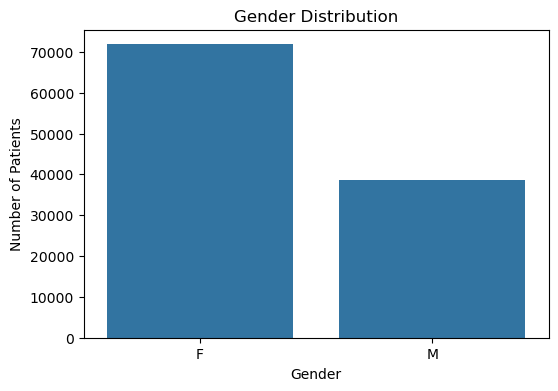

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

## Histogram

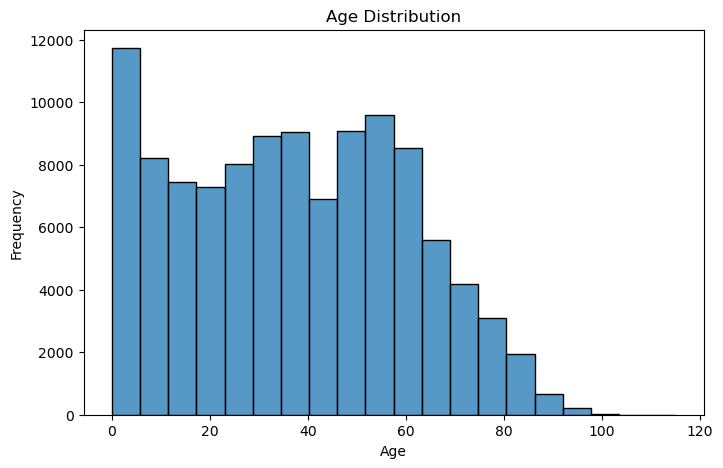

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Pie Chart

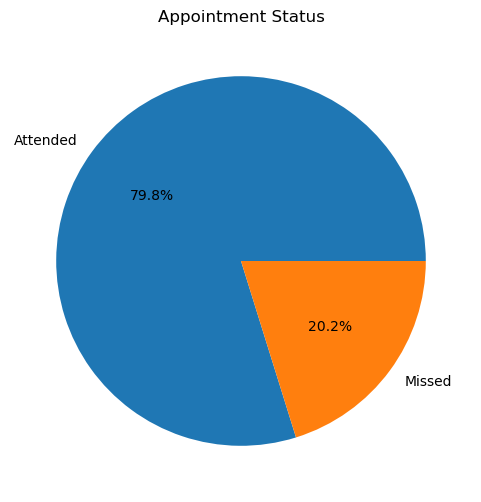

In [52]:
plt.figure(figsize=(6,6))

df["No_Show"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Attended","Missed"]
)

plt.title("Appointment Status")
plt.ylabel("")

plt.show()

## Grouped Bar Chart

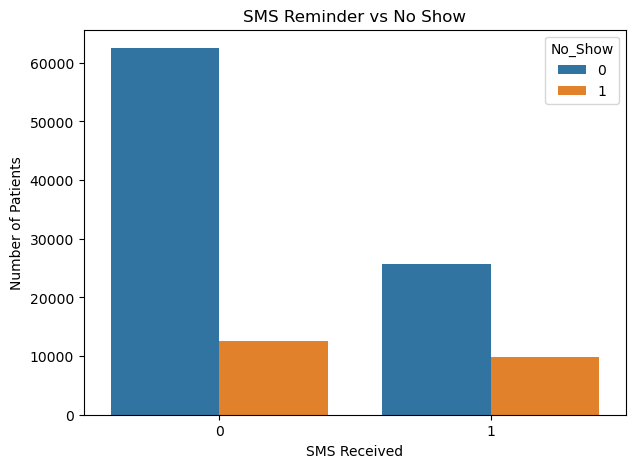

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="SMS_received",
    hue="No_Show",
    data=df
)

plt.title("SMS Reminder vs No Show")
plt.xlabel("SMS Received")
plt.ylabel("Number of Patients")

plt.show()

## Count Plot

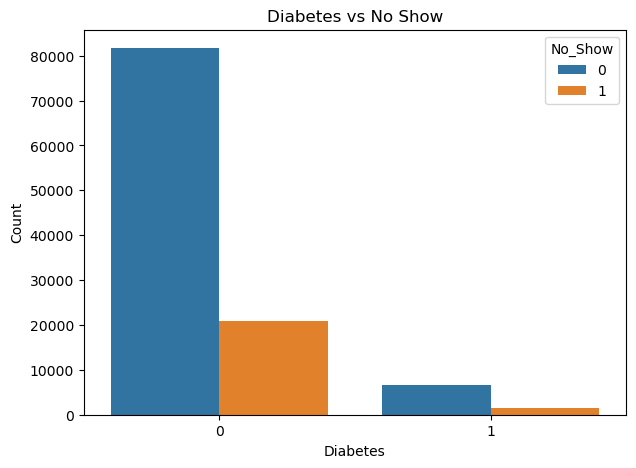

In [54]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Diabetes",
    hue="No_Show",
    data=df
)

plt.title("Diabetes vs No Show")
plt.xlabel("Diabetes")
plt.ylabel("Count")

plt.show()

## Histogram

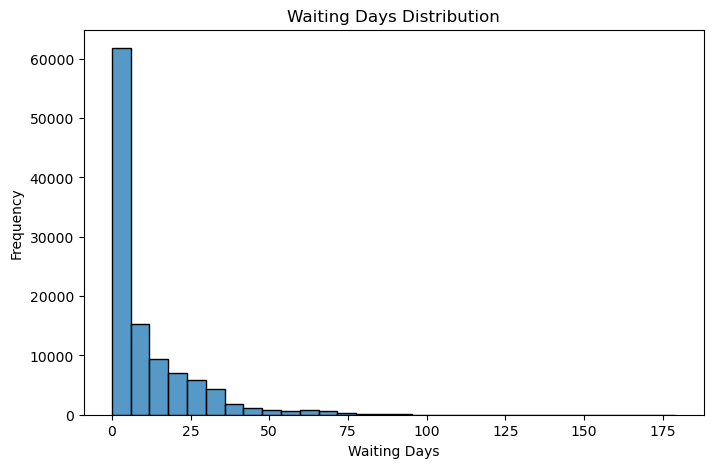

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(df["WaitingDays"], bins=30)

plt.title("Waiting Days Distribution")
plt.xlabel("Waiting Days")
plt.ylabel("Frequency")

plt.show()

## Count Plot

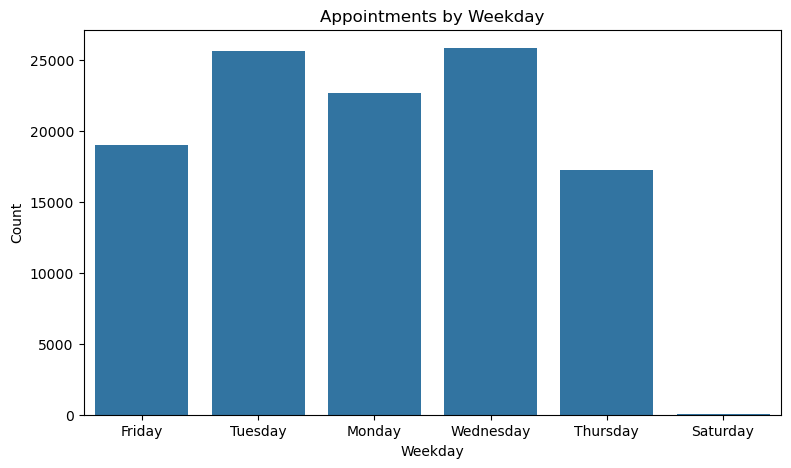

In [57]:
plt.figure(figsize=(9,5))

sns.countplot(
    x="Weekday",
    data=df
)

plt.title("Appointments by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Count")

plt.show()

## Correlation Heatmap

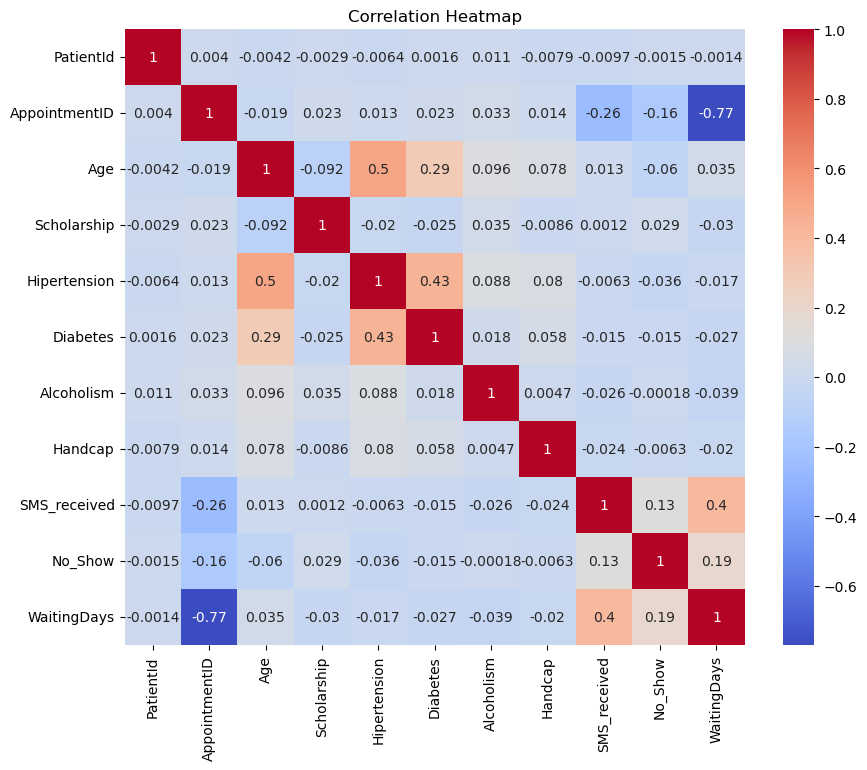

In [58]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Bar Chart

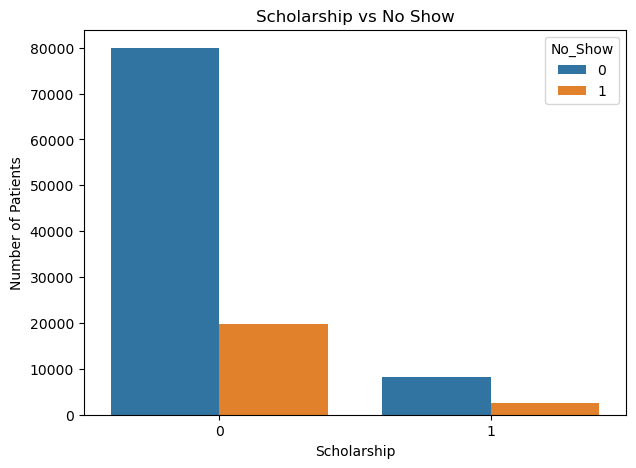

In [60]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Scholarship",
    hue="No_Show",
    data=df
)

plt.title("Scholarship vs No Show")
plt.xlabel("Scholarship")
plt.ylabel("Number of Patients")

plt.show()

## Box plot

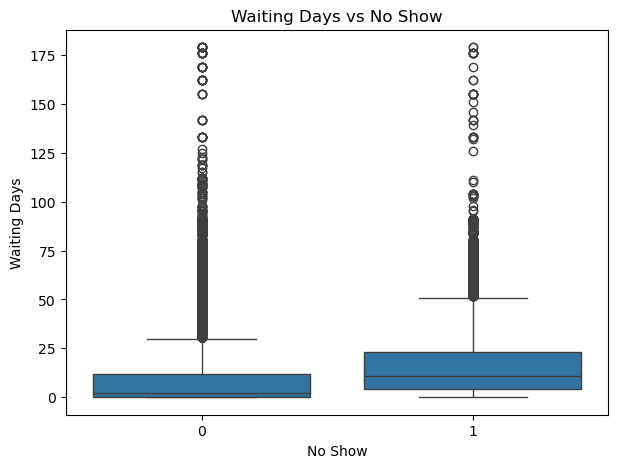

In [61]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="No_Show",
    y="WaitingDays",
    data=df
)

plt.title("Waiting Days vs No Show")
plt.xlabel("No Show")
plt.ylabel("Waiting Days")

plt.show()

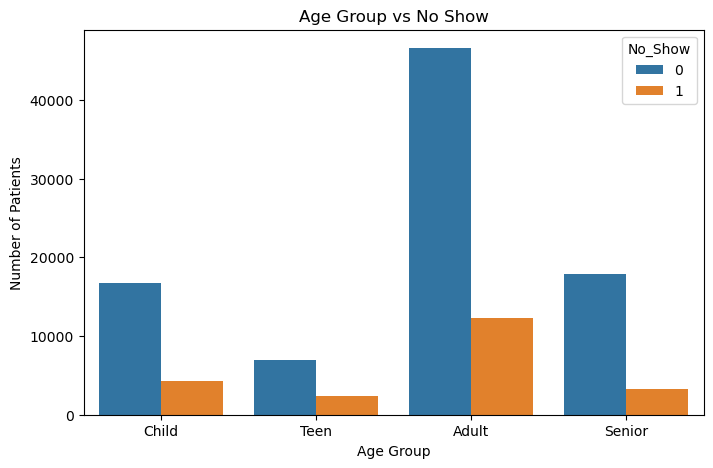

In [89]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AgeGroup",
    hue="No_Show"
)

plt.title("Age Group vs No Show")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.show()

## Data Preprocessing

In [108]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Neighbourhood"] = le.fit_transform(df["Neighbourhood"])
df["Weekday"] = le.fit_transform(df["Weekday"])

In [113]:
df[["Gender", "Neighbourhood", "Weekday"]].head()


,Gender,Neighbourhood,Weekday
0,0,39,0
1,1,39,0
2,0,45,0
3,0,54,0
4,0,39,0


In [115]:
print(X.dtypes)

PatientId          float64
AppointmentID        int64
Gender               int64
ScheduledDay        object
AppointmentDay      object
Age                  int64
Neighbourhood        int64
Scholarship          int64
Hypertension         int64
Diabetes             int64
Alcoholism           int64
Handicap             int64
SMS_received         int64
WaitingDays          int64
Weekday              int64
AgeGroup          category
dtype: object


In [116]:
print(X.select_dtypes(include=["object", "datetime"]).columns)

Index(['ScheduledDay', 'AppointmentDay'], dtype='object')


## Select Features

In [110]:
X = df.drop("No_Show", axis=1)
y = df["No_Show"]

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    
)

## Train the Model

In [103]:
df.dtypes

PatientId          float64
AppointmentID        int64
Gender               int64
ScheduledDay        object
AppointmentDay      object
Age                  int64
Neighbourhood        int64
Scholarship          int64
Hypertension         int64
Diabetes             int64
Alcoholism           int64
Handicap             int64
SMS_received         int64
No_Show              int64
WaitingDays          int64
Weekday              int64
AgeGroup          category
dtype: object